In [1]:
from mapping.software.database            import ElectrosprayDatabase
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import pandas as pd
import os
import sys

In [2]:
SAMPLE_RATE = 50_000  # Hz
NPY_DIR = "data/raw_waveforms"


In [3]:
BASE = Path(r"C:\Users\HV\Desktop\bruno_work\main\data")
db = ElectrosprayDatabase(str(BASE))
    

# 1. Load Data
df_db = db.load_training_dataframe()
print(f"✓ Loaded {len(df_db)} records from database")


[DB] Ready: C:\Users\HV\Desktop\bruno_work\main\data\data.db

--- Available Solutions in Database ---
[0] ew82
[1] NOISE
[DB] Loading samples for: ['NOISE']
[DB] Loaded 81 samples.
✓ Loaded 81 records from database


In [4]:
df_db

,id,timestamp,solution_name,hv_position,target_voltage,actual_voltage,actual_current_ps,flow_rate,mean_na,deviation_na,...,band_power_low,band_power_mid,band_power_high,band_power_v_high,rf_spray_mode,xgb_spray_mode,image_classification,manual_classification,video_file,raw_data_file
0,2706,2026-06-08T13:23:47.973694,NOISE,nozzle,0.0,627.56000,-2.076660e-06,0.0,-14.399362,7.941590,...,27.351130,31.085935,3.431713,2.746459e-13,dripping (54%),intermitent (59%),N/A,N/A,2026-06-08_13-23-17_NOISE.mp4,wf_2026-06-08_13-23-47_973694.npy
1,2707,2026-06-08T13:23:50.638302,NOISE,nozzle,0.0,76.88950,-1.975010e-07,0.0,-13.657627,7.560442,...,19.480805,29.871251,3.174738,2.159053e-13,dripping (54%),intermitent (67%),N/A,N/A,2026-06-08_13-23-17_NOISE.mp4,wf_2026-06-08_13-23-50_638302.npy
2,2708,2026-06-08T13:23:53.241475,NOISE,nozzle,0.0,18.43120,7.254300e-10,0.0,-13.252648,8.260032,...,29.246791,29.676376,3.118495,2.942220e-13,dripping (56%),dripping (68%),N/A,N/A,2026-06-08_13-23-17_NOISE.mp4,wf_2026-06-08_13-23-53_241475.npy
3,2709,2026-06-08T13:23:55.844570,NOISE,nozzle,0.0,5.70649,4.334440e-08,0.0,-14.498133,7.921057,...,19.741437,29.449162,3.145726,2.593511e-13,dripping (54%),intermitent (72%),N/A,N/A,2026-06-08_13-23-17_NOISE.mp4,wf_2026-06-08_13-23-55_844570.npy
4,2710,2026-06-08T13:23:58.460070,NOISE,nozzle,0.0,2.68701,5.268430e-08,0.0,-12.413767,7.659014,...,23.878999,29.148354,3.102373,2.320297e-13,dripping (58%),intermitent (49%),N/A,N/A,2026-06-08_13-23-17_NOISE.mp4,wf_2026-06-08_13-23-58_460070.npy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,2782,2026-06-08T13:33:25.041636,NOISE,nozzle,10000.0,9999.98000,6.570580e-07,9.0,-105.725475,267.586836,...,39.072203,11.605336,3.015648,1.274213e-09,multi_jet (58%),multi_jet (100%),multi_jet (63%),multi_jet,2026-06-08_13-27-49_NOISE.mp4,wf_2026-06-08_13-33-25_041636.npy
77,2783,2026-06-08T13:33:27.550398,NOISE,nozzle,10000.0,9999.97000,6.298550e-07,9.0,-116.606396,249.425481,...,36.264278,11.412869,3.201302,8.439600e-10,multi_jet (58%),multi_jet (100%),cone_jet (86%),cone_jet,2026-06-08_13-27-49_NOISE.mp4,wf_2026-06-08_13-33-27_550398.npy
78,2784,2026-06-08T13:33:30.054521,NOISE,nozzle,10000.0,9999.99000,6.474460e-07,9.0,-113.181202,254.752551,...,40.488650,10.984633,3.152675,1.221521e-09,multi_jet (58%),multi_jet (100%),cone_jet (98%),cone_jet,2026-06-08_13-27-49_NOISE.mp4,wf_2026-06-08_13-33-30_054521.npy
79,2785,2026-06-08T13:33:32.564800,NOISE,nozzle,10000.0,9999.96000,6.470840e-07,9.0,-89.390810,180.322392,...,33.608430,10.868222,3.028457,1.363115e-09,multi_jet (58%),multi_jet (100%),cone_jet (95%),cone_jet,2026-06-08_13-27-49_NOISE.mp4,wf_2026-06-08_13-33-32_564800.npy


In [9]:
EXCLUDE_FEATURES_MODIFIED = [
    "actual_current_ps",
    "current_PS",
    "voltage_error",
    "target_voltage",
    "variance_na", "rms_na", "band_power_v_low", "band_power_low", "band_power_mid", "band_power_high", "band_power_v_high", "peak", "crest_factor",
    "kurtosis", "skewness", "peak_to_peak", "zero_crossing_rate", "dominant_freq", "mean_freq", "spectral_entropy", "total_power", "wt_approx_L6_energy",
    "wt_approx_L6_energy_rel", "wt_detail_L6_energy", "wt_detail_L6_energy_rel", "wt_detail_L5_energy", "wt_detail_L5_energy_rel", "wt_detail_L4_energy",
    "wt_detail_L4_energy_rel", "wt_detail_L3_energy", "wt_detail_L3_energy_rel", "wt_detail_L2_energy", "wt_detail_L2_energy_rel", "wt_detail_L1_energy",
    "wt_detail_L1_energy_rel", "deviation_na", "median_na", "qty_max", "pct_max"
    # Add more features here if you want to exclude them
    # Example: "some_feature_name",
]
df_db = df_db.drop(
    columns=[c for c in EXCLUDE_FEATURES_MODIFIED if c in df_db.columns]
)

In [ ]:
df_db

In [6]:
def load_waveform(filename: str) -> np.ndarray | None:
    path = os.path.join(NPY_DIR, filename)
    if not os.path.exists(path):
        return None
    arr = np.load(path)
    return arr.flatten()
 
 
def format_classification(val):
    return str(val) if val not in (None, "", "N/A", float("nan")) else "—"

In [7]:
class WaveformViewer:
    # Colour palette
    BG        = "#0d1117"
    PANEL_BG  = "#161b22"
    ACCENT    = "#58a6ff"
    VOLT_CLR  = "#f0a500"
    FLOW_CLR  = "#3fb950"
    WAVE_CLR  = "#58a6ff"
    GRID_CLR  = "#21262d"
    TEXT_CLR  = "#e6edf3"
    MUTED_CLR = "#8b949e"
    WARN_CLR  = "#f85149"
 
    def __init__(self, dataframe: pd.DataFrame):
        self.df    = dataframe
        self.index = 0
        self.total = len(dataframe)
        self._build_figure()
        self._render()
 
    # ── Figure scaffold ──────────────────────────────────────────────────────
 
    def _build_figure(self):
        plt.rcParams.update({
            "figure.facecolor":  self.BG,
            "axes.facecolor":    self.PANEL_BG,
            "axes.edgecolor":    self.GRID_CLR,
            "axes.labelcolor":   self.TEXT_CLR,
            "xtick.color":       self.MUTED_CLR,
            "ytick.color":       self.MUTED_CLR,
            "grid.color":        self.GRID_CLR,
            "text.color":        self.TEXT_CLR,
            "font.family":       "monospace",
        })
 
        self.fig = plt.figure(figsize=(14, 8), facecolor=self.BG)
        self.fig.canvas.manager.set_window_title("Waveform Viewer")
 
        gs = gridspec.GridSpec(
            3, 1,
            figure=self.fig,
            height_ratios=[0.18, 0.14, 1],
            hspace=0.06,
            left=0.07, right=0.97, top=0.93, bottom=0.09,
        )
 
        # ── Title bar (text-only axis) ──
        self.ax_title = self.fig.add_subplot(gs[0])
        self.ax_title.set_axis_off()
 
        # ── Metadata bar ──
        self.ax_meta = self.fig.add_subplot(gs[1])
        self.ax_meta.set_axis_off()
 
        # ── Waveform ──
        self.ax_wave = self.fig.add_subplot(gs[2])
        self.ax_wave.grid(True, linewidth=0.4, alpha=0.6)
        self.ax_wave.set_xlabel("Time (s)", fontsize=9)
        self.ax_wave.set_ylabel("Current (nA)", fontsize=9)
 
        # Navigation hint at bottom
        self.fig.text(
            0.5, 0.01,
            "← / p  previous     → / n  next     q  quit",
            ha="center", va="bottom",
            fontsize=8, color=self.MUTED_CLR,
        )
 
        self.fig.canvas.mpl_connect("key_press_event", self._on_key)
 
    # ── Rendering ────────────────────────────────────────────────────────────
 
    def _render(self):
        row = self.df.iloc[self.index]
 
        # ── Title bar ──────────────────────────────────────────────────────
        self.ax_title.clear()
        self.ax_title.set_axis_off()
 
        # Progress pill
        progress_txt = f"  {self.index + 1} / {self.total}  "
        self.ax_title.text(
            0.0, 0.5, progress_txt,
            transform=self.ax_title.transAxes,
            fontsize=9, color=self.BG,
            va="center", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=self.ACCENT, edgecolor="none"),
        )
 
        # Solution name
        self.ax_title.text(
            0.08, 0.5, row["solution_name"],
            transform=self.ax_title.transAxes,
            fontsize=14, fontweight="bold",
            color=self.TEXT_CLR, va="center",
        )
 
        # Timestamp (right-aligned)
        self.ax_title.text(
            1.0, 0.5, row["timestamp"],
            transform=self.ax_title.transAxes,
            fontsize=8, color=self.MUTED_CLR,
            va="center", ha="right",
        )
 
        # ── Metadata bar ───────────────────────────────────────────────────
        self.ax_meta.clear()
        self.ax_meta.set_axis_off()
 
        meta_items = [
            ("VOLTAGE",   f"{row['actual_voltage']:.2f} V",   self.VOLT_CLR),
            ("FLOW RATE", f"{row['flow_rate']:.2f} µL/min",   self.FLOW_CLR),
            ("HV POS",    str(row["hv_position"]),             self.ACCENT),
            ("MEAN nA",   f"{row['mean_na']:.3f}",             self.TEXT_CLR),
            ("RF MODE",   format_classification(row["rf_spray_mode"]),  self.MUTED_CLR),
            ("XGB MODE",  format_classification(row["xgb_spray_mode"]), self.MUTED_CLR),
            ("IMG CLASS", format_classification(row["image_classification"]), self.MUTED_CLR),
            ("MANUAL",    format_classification(row["manual_classification"]), self.MUTED_CLR),
        ]
 
        x = 0.0
        for label, value, colour in meta_items:
            self.ax_meta.text(
                x, 0.80, label,
                transform=self.ax_meta.transAxes,
                fontsize=6.5, color=self.MUTED_CLR, va="top",
            )
            self.ax_meta.text(
                x, 0.35, value,
                transform=self.ax_meta.transAxes,
                fontsize=8.5, color=colour, va="top", fontweight="bold",
            )
            x += 0.125
 
        # ── Waveform ───────────────────────────────────────────────────────
        self.ax_wave.clear()
        self.ax_wave.set_facecolor(self.PANEL_BG)
        self.ax_wave.grid(True, linewidth=0.4, alpha=0.5, color=self.GRID_CLR)
        self.ax_wave.set_xlabel("Time (s)", fontsize=9, color=self.MUTED_CLR)
        self.ax_wave.set_ylabel("Current (nA)", fontsize=9, color=self.MUTED_CLR)
        self.ax_wave.tick_params(labelsize=8)
 
        # Voltage & flow rate horizontal reference lines
        v_norm = row["actual_voltage"]
        fr_norm = row["flow_rate"]
 
        waveform = load_waveform(row["raw_data_file"])
 
        if waveform is not None:
            n = len(waveform)
            t = np.linspace(0, n / SAMPLE_RATE, n)
            self.ax_wave.plot(t, waveform, color=self.WAVE_CLR, linewidth=0.5, alpha=0.9)
 
            # Overlay mean line
            mean_val = np.mean(waveform)
            self.ax_wave.axhline(
                mean_val, color=self.ACCENT, linewidth=1.0,
                linestyle="--", alpha=0.7,
                label=f"mean = {mean_val:.2f} nA",
            )
 
            self.ax_wave.set_xlim(t[0], t[-1])
            self.ax_wave.set_title(
                row["raw_data_file"],
                fontsize=8, color=self.MUTED_CLR, pad=4,
            )
            self.ax_wave.legend(
                fontsize=8, facecolor=self.PANEL_BG,
                edgecolor=self.GRID_CLR, labelcolor=self.TEXT_CLR,
                loc="upper right",
            )
        else:
            # File not found — show a clear warning
            self.ax_wave.text(
                0.5, 0.5,
                f"⚠  File not found:\n{row['raw_data_file']}",
                transform=self.ax_wave.transAxes,
                fontsize=11, color=self.WARN_CLR,
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.6", facecolor=self.PANEL_BG, edgecolor=self.WARN_CLR),
            )
 
        # Voltage annotation (top-right corner of wave panel)
        self.ax_wave.annotate(
            f"⚡ {v_norm:.1f} V",
            xy=(0.01, 0.97), xycoords="axes fraction",
            fontsize=9, color=self.VOLT_CLR, va="top",
            fontweight="bold",
        )
        self.ax_wave.annotate(
            f"💧 {fr_norm:.2f} µL/min",
            xy=(0.01, 0.88), xycoords="axes fraction",
            fontsize=9, color=self.FLOW_CLR, va="top",
            fontweight="bold",
        )
 
        self.fig.canvas.draw_idle()
 
    # ── Key handler ──────────────────────────────────────────────────────────
 
    def _on_key(self, event):
        if event.key in ("right", "n"):
            if self.index < self.total - 1:
                self.index += 1
                self._render()
            else:
                print("Already at last record.")
        elif event.key in ("left", "p"):
            if self.index > 0:
                self.index -= 1
                self._render()
            else:
                print("Already at first record.")
        elif event.key == "q":
            plt.close("all")
            sys.exit(0)
 
    def show(self):
        plt.show()

C:\Users\HV\AppData\Local\Temp\ipykernel_15784\1829536987.py:197: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans Mono.
  self.fig.canvas.draw_idle()
c:\Users\HV\Desktop\bruno_work\main\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


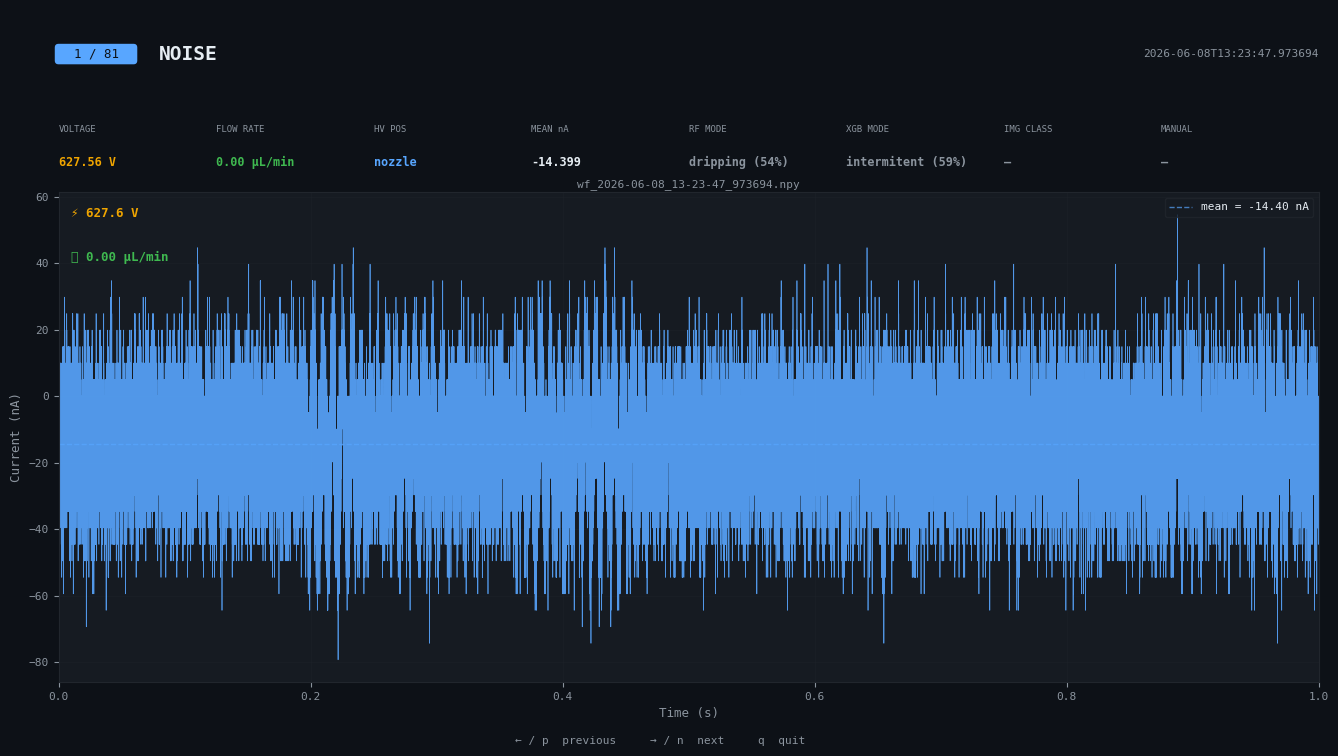

In [8]:
viewer = WaveformViewer(df_db)
viewer.show()